In [8]:
import numpy as np
import matplotlib.pyplot as plt

from stream_perturbing_halos import (
    find_mw_halos,
    fetch_subhalos,
    perturbations_per_kpc,
    population_perturbation_rates,
    MW_HALO_MASS_MSUN,
    PERTURBER_MASS_MSUN,
    PERTURBER_R_RANGE_KPC,
    H_HUBBLE,
)

params = {
    "text.usetex": False,
    "font.family": "serif",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.left": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.size": 2.5,
    "xtick.major.size": 5,
    "ytick.minor.size": 2.5,
    "ytick.major.size": 5,
    "axes.axisbelow": False,
    "figure.dpi": 300,
}
plt.rcParams.update(params)

In [9]:
mw = find_mw_halos()
print(
    f"{len(mw)} MW analogs in M_central = "
    f"[{MW_HALO_MASS_MSUN[0]:.0e}, {MW_HALO_MASS_MSUN[1]:.0e}] Msun"
)
print(f"index range: {min(mw)}..{max(mw)}")
print(f"first 10: {mw[:10]}")

103 MW analogs in M_central = [1e+12, 2e+12] Msun
index range: 77..241
first 10: [77, 85, 89, 90, 95, 103, 106, 108, 112, 113]


In [23]:
from colossus.lss import peaks
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck18')

# Constants
k_B   = 1.381e-16    # erg/K
c_cgs = 2.998e10     # cm/s
eV    = 1.602e-12    # erg
keV   = 1.0e3 * eV   # erg
T_CMB = 2.725        # K
Mpc_cm = 3.086e24    # cm per Mpc

m_wdm = 1.0 * keV    # rest-mass energy of the WDM particle [erg]
z_nr = m_wdm/(k_B * T_CMB) - 1
print(z_nr)
t_nr = 1318860.210  # seconds (age of the Universe at z_nr) (From Ned Wright's cosmology calculator)


lambda_fs_cm = c_cgs * t_nr * (1 + z_nr)
lambda_fs_Mpc = lambda_fs_cm/Mpc_cm
print(f"{lambda_fs_Mpc:.3e}")
M_suppressed = H_HUBBLE * peaks.lagrangianM(lambda_fs_Mpc/H_HUBBLE) # In units of M_sun
print(f"{M_suppressed:.3e}")

4256986.025755835
5.454e-02
1.279e+08


In [11]:
sh = fetch_subhalos(mw[0], mass_range_msun=[M_suppressed, PERTURBER_MASS_MSUN[1]])  # halo 77
for k, v in sh.items():
    print(
        f"  {k:14s} shape={getattr(v, 'shape', None)} dtype={getattr(v, 'dtype', None)}"
    )

print(f"\nN subhalos in [1e6, 1e9] Msun: {len(sh['id'])}")
print(f"M range: {sh['mass_msun'].min():.2e} to {sh['mass_msun'].max():.2e} Msun")
print(f"R range: {sh['R_kpc'].min():.2f} to {sh['R_kpc'].max():.2f} kpc")
print(f"halo center (sim coords): {sh['halo_pos_kpc']}")

  id             shape=(136,) dtype=int64
  mass_msun      shape=(136,) dtype=float64
  pos_kpc        shape=(136, 3) dtype=float64
  R_kpc          shape=(136,) dtype=float64
  halo_pos_kpc   shape=(3,) dtype=float64

N subhalos in [1e6, 1e9] Msun: 136
M range: 1.29e+08 to 9.93e+08 Msun
R range: 68.21 to 1486.45 kpc
halo center (sim coords): [19701.51267715 45124.69264375 31624.49600495]


In [12]:
sh = {"id": [], "mass_msun": [], "R_kpc": [], "halo_pos_kpc": []}
n_subhalos = 0
for i in mw:
    subhalos = fetch_subhalos(i, mass_range_msun=[M_suppressed, PERTURBER_MASS_MSUN[1]])
    for k in sh:
        sh[k].extend(subhalos[k])
for k in sh:
    sh[k] = np.array(sh[k])

wdm_suppress_mask = sh['mass_msun'] > M_suppressed

for k in sh:
    if k != "halo_pos_kpc":
        sh[k] = sh[k][wdm_suppress_mask]

print(f"\nN subhalos in [1e6, 1e9] Msun: {len(sh['id'])}")
print(f"M range: {sh['mass_msun'].min():.2e} to {sh['mass_msun'].max():.2e} Msun")
print(f"R range: {sh['R_kpc'].min():.2f} to {sh['R_kpc'].max():.2f} kpc")


N subhalos in [1e6, 1e9] Msun: 6793
M range: 1.28e+08 to 9.99e+08 Msun
R range: 1.76 to 51542.27 kpc


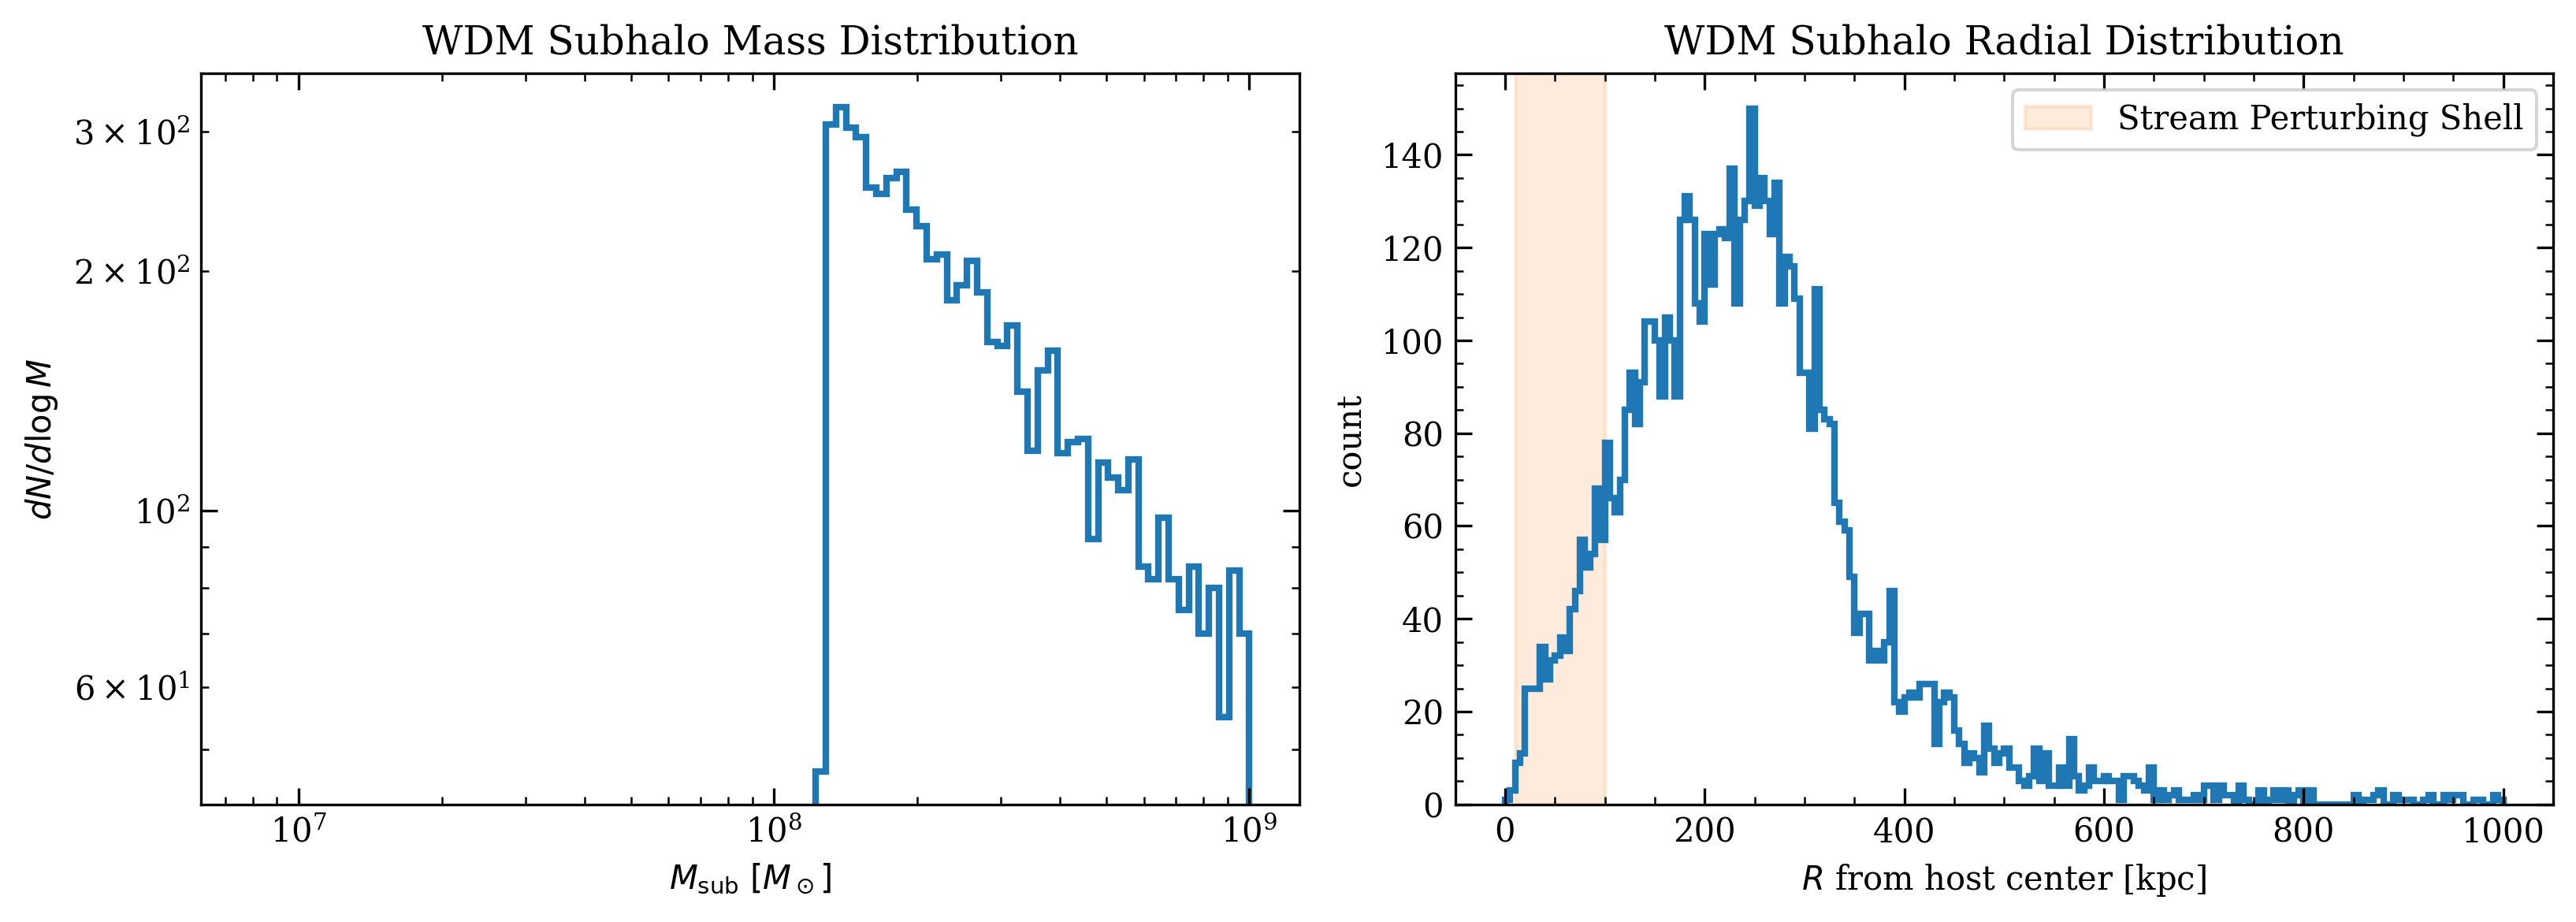

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Mass function
mbins = np.logspace(6.9, 9, 100)
axes[0].hist(sh["mass_msun"], bins=mbins, histtype="step", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$M_{\rm sub}\ [M_\odot]$")
axes[0].set_ylabel(r"$dN/d\log M$")
axes[0].set_title("WDM Subhalo Mass Distribution")

# Radial distribution
axes[1].hist(sh["R_kpc"], bins=200, histtype="step", lw=2, range=[0, 1000])
axes[1].axvspan(
    *PERTURBER_R_RANGE_KPC, color="C1", alpha=0.15, label="Stream Perturbing Shell"
)
axes[1].set_xlabel(r"$R$ from host center [kpc]")
axes[1].set_ylabel("count")
axes[1].set_title("WDM Subhalo Radial Distribution")
axes[1].legend()
fig.tight_layout()
fig.savefig("./plots/subhalo_mass_and_radial_distributions_wdm.png", dpi=300)

WDM N_perturb/kpc @ GD-1 (D=8 kpc, T=12 Gyr):
  median = 0.016
  1-sigma range = 0.00494 – 0.027
  full range across 103 hosts: 0 – 0.0574


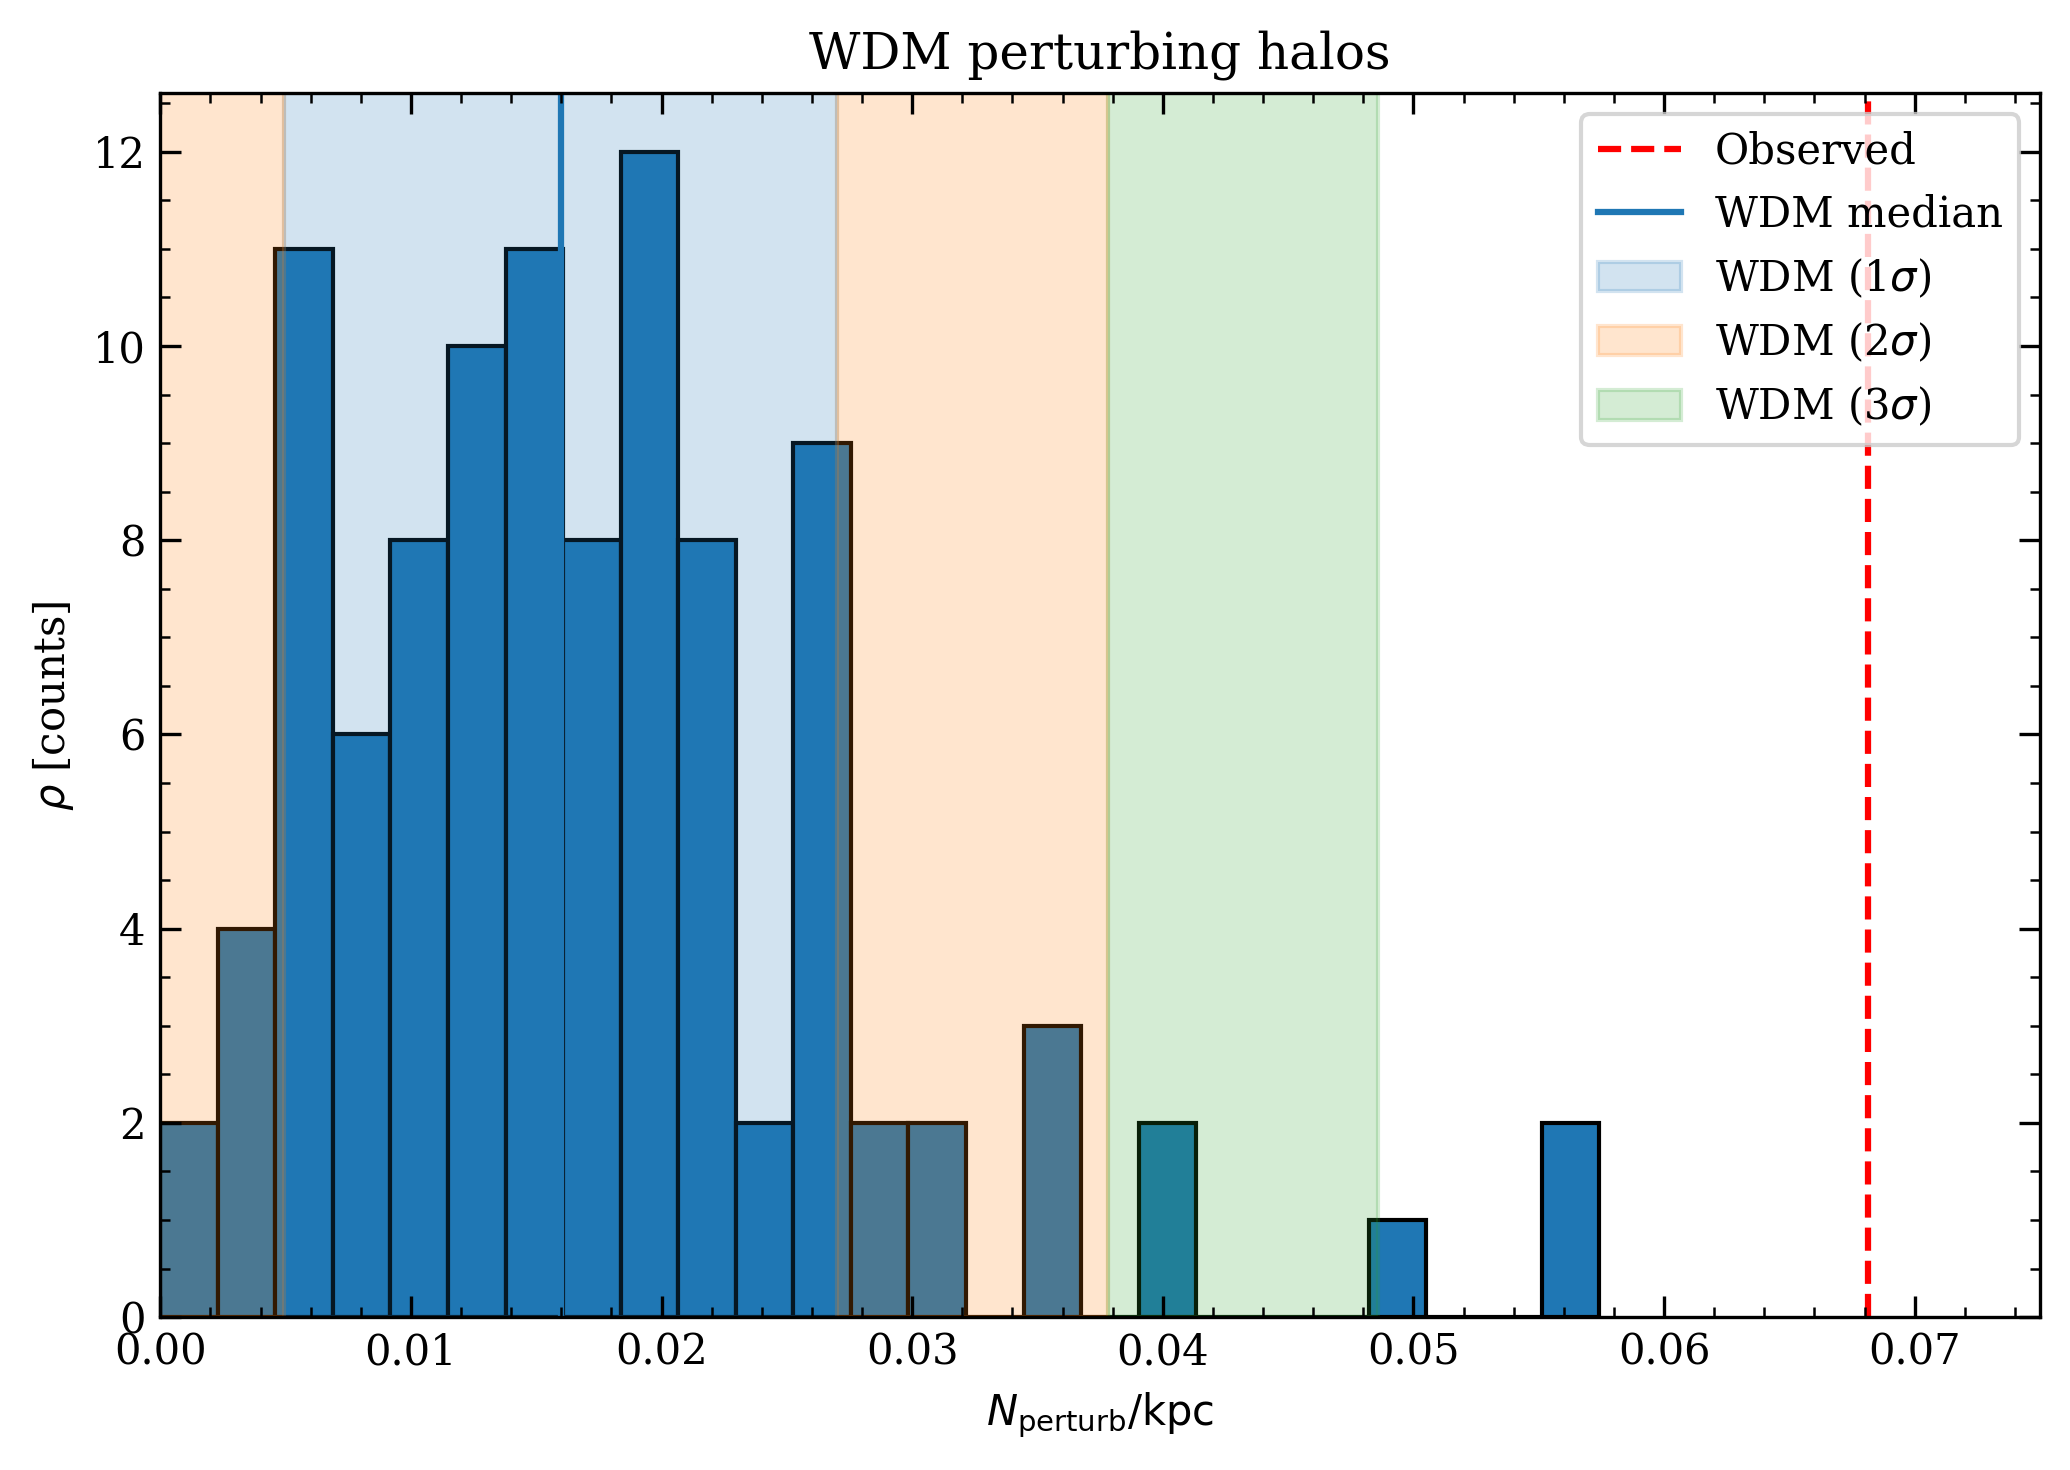

In [19]:
pop = population_perturbation_rates(mass_range_msun=[M_suppressed, PERTURBER_MASS_MSUN[1]])

med = np.median(pop["per_kpc"])
std = np.std(pop["per_kpc"])
poneminus = np.max(pop["per_kpc"][pop["per_kpc"] < med - std])
poneplus = np.min(pop["per_kpc"][pop["per_kpc"] > med + std])
p2minus = poneminus - std
p2plus = poneplus + std
p3minus = poneminus - 2*std
p3plus = poneplus + 2*std
print("WDM N_perturb/kpc @ GD-1 (D=8 kpc, T=12 Gyr):")
print(f"  median = {med:.3g}")
print(f"  1-sigma range = {poneminus:.3g} – {poneplus:.3g}")
print(
    f"  full range across {len(pop['per_kpc'])} hosts:"
    f" {pop['per_kpc'].min():.3g} – {pop['per_kpc'].max():.3g}"
)

plt.figure(figsize=(7, 5))
plt.hist(pop["per_kpc"], bins=25, edgecolor="k")
plt.axvline(9 / 132.1, color="red", ls="--", label="Observed")
plt.axvline(med, color="C0", label="WDM median")
plt.axvspan(poneminus, poneplus, color="C0", alpha=0.2, label=r"WDM (1$\sigma$)")
plt.axvspan(p2minus, poneminus, color="C1", alpha=0.2, label=r"WDM (2$\sigma$)")
plt.axvspan(poneplus, p2plus, color="C1", alpha=0.2)
plt.axvspan(p3minus, p2minus, color="C2", alpha=0.2, label=r"WDM (3$\sigma$)")
plt.axvspan(p2plus, p3plus, color="C2", alpha=0.2)
plt.xlabel(r"$N_{\rm perturb}/{\rm kpc}$")
plt.ylabel(r"$\rho$ [counts]")
plt.gca().set_xlim(0,0.075)
plt.title("WDM perturbing halos")
plt.legend()
plt.tight_layout()
plt.savefig("./plots/stream_perturbation_rate_distribution_wdm.png", dpi=300)
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Mass function
mbins = np.logspace(6.9, 9, 100)
axes[0].hist(sh["mass_msun"], bins=mbins, histtype="step", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$M_{\rm sub}\ [M_\odot]$")
axes[0].set_ylabel(r"$dN/d\log M$")
axes[0].set_title("WDM Subhalo Mass Distribution")

# Radial distribution
axes[1].hist(sh["R_kpc"], bins=200, histtype="step", lw=2, range=[0, 1000])
axes[1].axvspan(
    *PERTURBER_R_RANGE_KPC, color="C1", alpha=0.15, label="Stream Perturbing Shell"
)
axes[1].set_xlabel(r"$R$ from host center [kpc]")
axes[1].set_ylabel("count")
axes[1].set_title("WDM Subhalo Radial Distribution")
axes[1].legend()
fig.tight_layout()
fig.savefig("./plots/subhalo_mass_and_radial_distributions_wdm.png", dpi=300)